In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve
import joblib

import warnings
warnings.filterwarnings("ignore")

# 1. Load & Prepare Data

In [2]:
df = pd.read_csv("/kaggle/input/datasets/pheobebuffe/numero-esim-purchases/Copy of Numero eSIM_purchases (2024 - 2025).csv")

df['purchase_date'] = pd.to_datetime(df['purchase_date'])
df['register_date']  = pd.to_datetime(df['register_date'])
df = df.rename(columns={'prodcut': 'product'})
df['price'] = df['price'].fillna(df['price'].mean())

# Sets 'today' as the most recent purchase date in the dataset (since it's historical data) to use as a reference point for recency and reactivation calculations.
today = df['purchase_date'].max()

# The company requested we group the 8 products into 3 super classes, and perform a seperate clustering algorithm on each super class.
product_group_map = {
    'Phone Number':       'Virtual Number',
    'Local Calling Plan': 'Virtual Number',
    'EU Bundle':          'Virtual Number',
    'Full eSIM':          'Data eSIM',
    'Local eSIM':         'Data eSIM',
    'Data eSIM':          'Data eSIM',
    'Calling Offers':     'Calls',
    'Recharge':           'Calls',
}

df['product_group'] = df['product'].map(product_group_map)

print(df.shape)
df.head()

(826859, 14)


,id_client,purchase_date,product,product_type,details,renewal_status,price,User Country,User phone number,register_date,platform,email,language,product_group
0,15736044,2024-01-01,Data eSIM,Germany,1 GB,New,2.5,Germany,4915219617737,2024-01-01,iOS,NaN,english,Data eSIM
1,15736461,2024-01-01,Data eSIM,Spain,1 GB,New,3.0,Tunisia,21622062281,2024-01-01,iOS,NaN,french,Data eSIM
2,15736510,2024-01-01,Data eSIM,China,1 GB,New,5.0,Colombia,573155801176,2024-01-01,Android,NaN,spanish,Data eSIM
3,15736510,2024-01-01,Data eSIM,Indonesia,1 GB,New,5.0,Colombia,573155801176,2024-01-01,Android,NaN,spanish,Data eSIM
4,15737233,2024-01-01,Data eSIM,Australia,1 GB,New,4.0,Egypt,201018518052,2024-01-01,Android,NaN,arabic,Data eSIM


# 2. Client Feature Engineering (per Product Group)

In [3]:
def build_client_features(df_group, today):
    g = df_group.copy()

    # Groups data by client ID and computes customer-level metrics like recency, age, purchase history, 
    # spending totals, averages, variability, and product diversity, then resets the index.
    base = g.groupby('id_client').agg(
        recency          = ('purchase_date', lambda x: (today - x.max()).days),
        customer_age     = ('register_date', lambda x: (today - x.min()).days),
        first_purchase   = ('purchase_date', 'min'),
        last_purchase    = ('purchase_date', 'max'),
        total_purchases  = ('price', 'count'),
        total_spent      = ('price', 'sum'),
        avg_order_value  = ('price', 'mean'),
        std_order_value  = ('price', 'std'),
        unique_products  = ('product',  'nunique'),
    ).reset_index()

    # Replaces NaN std (from single purchases) with 0, then calculates purchase velocity as 
    # purchases per month over the customer’s active period (avoiding division by zero)
    base['std_order_value'] = base['std_order_value'].fillna(0)

    active_days = (base['last_purchase'] - base['first_purchase']).dt.days
    base['purchase_velocity'] = (
        base['total_purchases'] / (active_days.clip(lower=1) / 30)
    )

    # Computes each client's average days between purchases and merges it into the base table, 
    # filling missing values (single purchase cases) with their total active period
    gaps = (g.sort_values(['id_client', 'purchase_date'])
             .groupby('id_client')['purchase_date']
             .apply(lambda x: x.diff().dt.days.mean()))
    base = base.merge(gaps.rename('avg_gap_days').reset_index(), on='id_client', how='left')
    base['avg_gap_days'] = base['avg_gap_days'].fillna(active_days)

    # Calculates each client's total spend per product and converts it into spend shares, 
    # merges these features into the base table, removes raw date columns, and returns the final dataset
    prod_spend = (g.groupby(['id_client', 'product'])['price']
                   .sum().unstack(fill_value=0).reset_index())
    prod_spend.columns = ['id_client'] + [
        f'spend_{c.lower().replace(" ", "_")}' for c in prod_spend.columns[1:]
    ]
    total = prod_spend.drop(columns='id_client').sum(axis=1).replace(0, np.nan)
    for c in prod_spend.columns[1:]:
        prod_spend[c.replace('spend_', 'share_')] = prod_spend[c] / total

    base = base.merge(prod_spend, on='id_client', how='left')
    base = base.drop(columns=['first_purchase', 'last_purchase'])
    return base

In [4]:
def cluster_clients(client_df, n_clusters, group_name):
    # Selects all features except client ID, fills missing values, and standardizes them
    feature_cols = [c for c in client_df.columns if c != 'id_client']

    X = client_df[feature_cols].fillna(0)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Applies PCA to reduce dimensionality while preserving 90% of variance and prints summary info
    pca = PCA(n_components=0.90, random_state=42)
    X_pca = pca.fit_transform(X_scaled)
    print(f"[{group_name}] PCA: {pca.n_components_} components → "
          f"{pca.explained_variance_ratio_.sum():.1%} variance explained")

    # Performs KMeans clustering on the transformed data to assign each client to a cluster
    km = KMeans(n_clusters=n_clusters, random_state=42, n_init=15)
    labels = km.fit_predict(X_pca)

    # Returns the original data with cluster labels and first two principal components, along with the PCA and scaler objects
    out = client_df.copy()
    out['cluster'] = labels
    out['PC1']     = X_pca[:, 0]
    out['PC2']     = X_pca[:, 1]
    return out, pca, scaler

In [5]:
def plot_cluster_profile(client_df, group_name):
    # Computes average key metrics per cluster and visualizes them:
    key_metrics = [
        'recency', 'customer_age', 'total_purchases', 'total_spent',
        'avg_order_value', 'unique_products', 'purchase_velocity', 'avg_gap_days',
    ]
    
    profile = client_df.groupby('cluster')[key_metrics].mean().round(2)

    # Normalised heatmap
    norm = MinMaxScaler().fit_transform(profile[key_metrics])
    norm_df = pd.DataFrame(norm, index=profile.index, columns=key_metrics)

    fig, axes = plt.subplots(1, 3, figsize=(22, 5))
    fig.suptitle(f'Cluster Profiles — {group_name}', fontsize=13)

    # 1. Heatmap
    sns.heatmap(norm_df, annot=profile.values, fmt='.1f',
                cmap='YlOrRd', linewidths=0.5, ax=axes[0],
                cbar_kws={'label': 'Normalised'})
    axes[0].set_title('Profile Heatmap (raw values shown)')
    axes[0].set_xlabel('Feature'); axes[0].set_ylabel('Cluster')

    # 2. PCA scatter
    sns.scatterplot(data=client_df, x='PC1', y='PC2',
                    hue='cluster', palette='tab10', s=25, alpha=0.7, ax=axes[1])
    axes[1].set_title('PCA Scatter (PC1 vs PC2)')
    axes[1].legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left')

    # 3. Total spend box
    sns.boxplot(data=client_df, x='cluster', y='total_spent',
                palette='tab10', showfliers=False, ax=axes[2])
    axes[2].set_title('Total Spent by Cluster')

    plt.tight_layout()
    plt.show()

    print(profile.to_string())
    print()

---
# 3. Calls — Client Clustering

In [6]:
df_calls = df[df['product_group'] == 'Calls'].copy()
calls_clients = build_client_features(df_calls, today)
print(f"Calls: {calls_clients.shape[0]:,} unique clients, {calls_clients.shape[1]} features")

Calls: 57,197 unique clients, 14 features


In [7]:
# Sets number of clusters to 2, applies clustering on the calls dataset, and prints the count of clients in each resulting cluster
CALLS_K = 2   

calls_clustered, calls_pca, calls_scaler = cluster_clients(calls_clients, CALLS_K, 'Calls')
print(calls_clustered['cluster'].value_counts().sort_index())

[Calls] PCA: 8 components → 91.6% variance explained
cluster
0    44432
1    12765
Name: count, dtype: int64


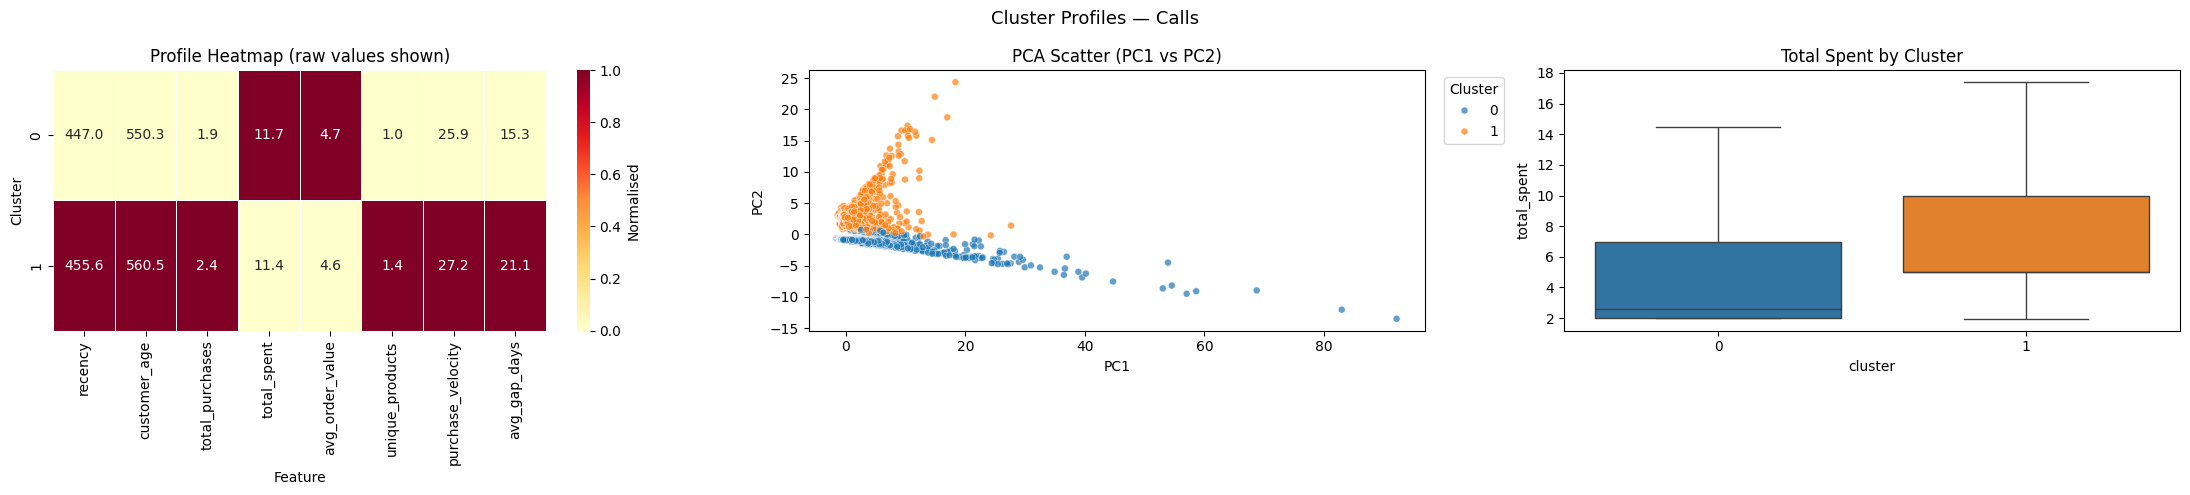

         recency  customer_age  total_purchases  total_spent  avg_order_value  unique_products  purchase_velocity  avg_gap_days
cluster                                                                                                                        
0         446.96        550.27             1.90        11.74             4.69             1.01              25.88         15.33
1         455.61        560.47             2.36        11.44             4.64             1.41              27.22         21.13



In [8]:
plot_cluster_profile(calls_clustered, 'Calls')

In [9]:
calls_clustered.groupby('cluster').mean(numeric_only=True)

,id_client,recency,customer_age,total_purchases,total_spent,avg_order_value,std_order_value,unique_products,purchase_velocity,avg_gap_days,spend_calling_offers,spend_recharge,share_calling_offers,share_recharge,PC1,PC2
cluster,,,,,,,,,,,,,,,,
0,1.833091e+07,446.960344,550.265327,1.902908,11.740451,4.694645,0.865284,1.005221,25.878096,15.330980,0.020368,11.720082,0.000382,0.999618,-0.070151,-0.806769
1,1.819563e+07,455.607129,560.474814,2.356052,11.441040,4.644000,0.980435,1.407599,27.217477,21.132571,7.323570,4.117470,0.809743,0.190257,0.244180,2.808176


| Cluster | Segment Name        | Value     | Behavior  | Strategy         |
| ------- | ------------------- | --------- | --------- | ---------------- |
| 0       | Infrequent Casual Callers   | Low–Medium    | Low       | Introduce calling bundles via trial offers |
| 1       | Regular Calling Offer Users  | High   | High  | Upsell higher-value calling bundles     |

In [10]:
# Maps numeric cluster labels to descriptive names for easier interpretation and previews the updated dataset with cluster names included
calls_cluster_names = {
    0: 'Calls - Infrequent Casual Users',
    1: 'Calls - Regular Calling Offer Users'
}

calls_clustered['cluster_name'] = calls_clustered['cluster'].map(calls_cluster_names)
calls_clustered.head()

,id_client,recency,customer_age,total_purchases,total_spent,avg_order_value,std_order_value,unique_products,purchase_velocity,avg_gap_days,spend_calling_offers,spend_recharge,share_calling_offers,share_recharge,cluster,PC1,PC2,cluster_name
0,15735920,730,730,1,2.0,2.0,0.0,1,30.000000,0.0,0.0,2.0,0.0,1.0,0,-1.169397,-0.642152,Calls - Infrequent Casual Users
1,15735936,730,730,1,2.0,2.0,0.0,1,30.000000,0.0,0.0,2.0,0.0,1.0,0,-1.169397,-0.642152,Calls - Infrequent Casual Users
2,15735986,730,730,1,2.0,2.0,0.0,1,30.000000,0.0,0.0,2.0,0.0,1.0,0,-1.169397,-0.642152,Calls - Infrequent Casual Users
3,15736016,720,730,2,4.0,2.0,0.0,1,8.571429,7.0,0.0,4.0,0.0,1.0,0,-0.685326,-0.658307,Calls - Infrequent Casual Users
4,15736376,671,730,6,12.0,2.0,0.0,1,3.050847,11.8,0.0,12.0,0.0,1.0,0,0.063638,-0.673053,Calls - Infrequent Casual Users


In [11]:
calls_clustered.to_csv('Client_Calls_Clustered.csv', index=False)
print("Saved: Client_Calls_Clustered.csv")

Saved: Client_Calls_Clustered.csv


---
# 4. Data eSIM — Client Clustering

In [12]:
df_esim = df[df['product_group'] == 'Data eSIM'].copy()
esim_clients = build_client_features(df_esim, today)
print(f"eSIM: {esim_clients.shape[0]:,} unique clients, {esim_clients.shape[1]} features")

eSIM: 73,125 unique clients, 16 features


In [13]:
# Sets number of clusters to 3, applies clustering on the esim dataset, and prints the count of clients in each resulting cluster
ESIM_K = 3   

esim_clustered, esim_pca, esim_scaler = cluster_clients(esim_clients, ESIM_K, 'Data eSIM')
print(esim_clustered['cluster'].value_counts().sort_index())

[Data eSIM] PCA: 8 components → 90.5% variance explained
cluster
0     6504
1    14703
2    51918
Name: count, dtype: int64


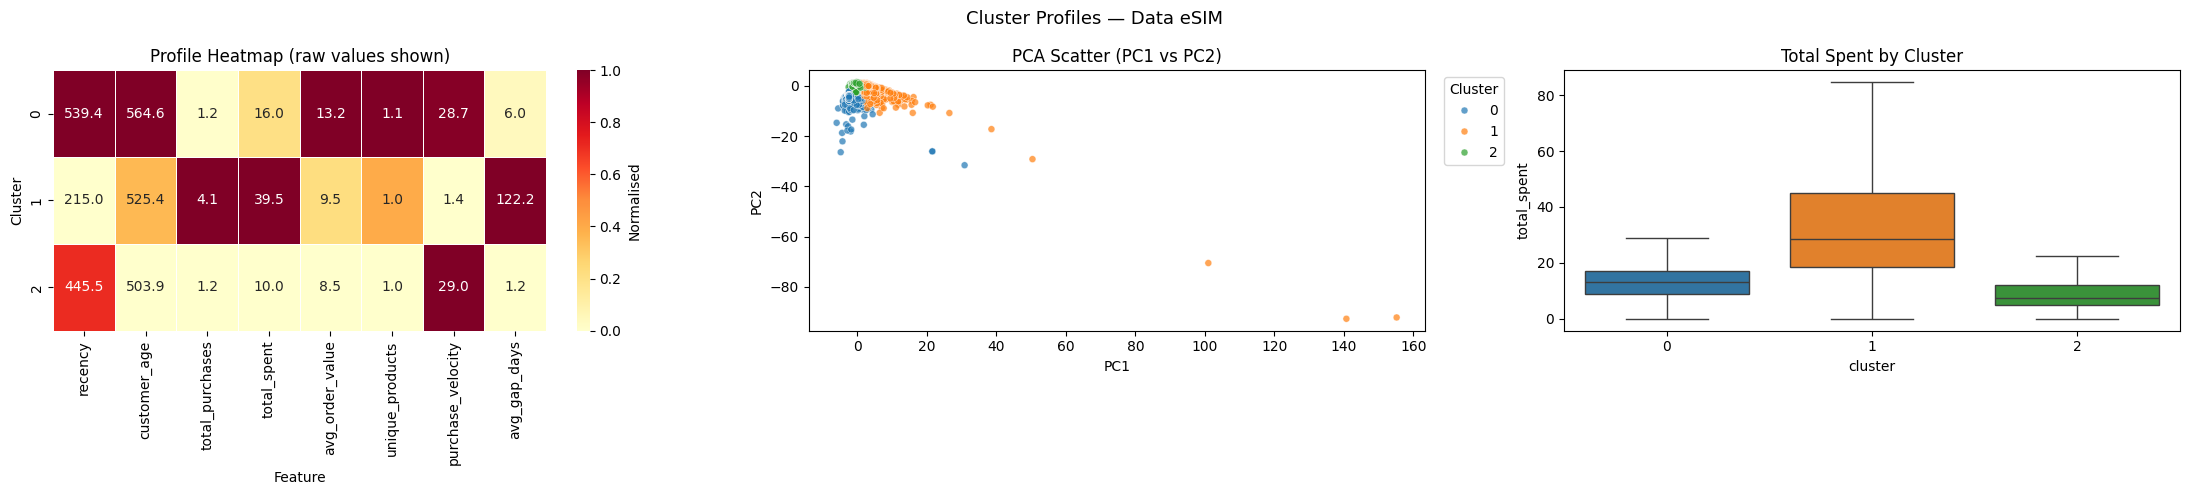

         recency  customer_age  total_purchases  total_spent  avg_order_value  unique_products  purchase_velocity  avg_gap_days
cluster                                                                                                                        
0         539.35        564.57             1.22        15.99            13.22             1.10              28.70          6.00
1         215.04        525.39             4.13        39.48             9.51             1.04               1.37        122.20
2         445.46        503.91             1.20        10.00             8.46             1.00              29.03          1.18



In [14]:
plot_cluster_profile(esim_clustered, 'Data eSIM')

In [15]:
esim_clustered.groupby('cluster').mean(numeric_only=True)

,id_client,recency,customer_age,total_purchases,total_spent,avg_order_value,std_order_value,unique_products,purchase_velocity,avg_gap_days,spend_data_esim,spend_full_esim,spend_local_esim,share_data_esim,share_full_esim,share_local_esim,PC1,PC2
cluster,,,,,,,,,,,,,,,,,,
0,1.814654e+07,539.352706,564.573647,1.222786,15.991907,13.217979,0.665784,1.103782,28.699659,6.003900,1.631316,0.014723,14.345867,0.038053,0.000402,0.961545,-2.463765,-4.585528
1,1.867047e+07,215.037883,525.387812,4.128273,39.480337,9.512212,3.955757,1.042576,1.367517,122.195004,39.031968,0.253195,0.195174,0.984868,0.010432,0.004700,2.620375,-0.132156
2,1.895850e+07,445.460457,503.907181,1.198852,9.995651,8.459972,0.323854,1.000347,29.031028,1.178153,9.944928,0.050723,0.000000,0.991767,0.008233,0.000000,-0.433434,0.611876


| Cluster | Segment Name       | Value  | Behavior               | Strategy           | 
| ------- | ------------------ | ------ | ---------------------- | ------------------ |
| 0       | High-Velocity Light Spenders    | Medium |  Buys frequently but cheaply | Bundle upgrade nudge |
| 1       | High-Value Bundle Subscribers | Highest   | Highest spend      | Retain with VIP perks    |
| 2       | Dormant Local Data Users   | Low/At-Risk    | One-time, low spend      | Re-engagement campaign |

In [16]:
# Maps numeric cluster labels to descriptive names for easier interpretation and previews the updated dataset with cluster names included
esim_cluster_names = {
    0: 'eSIM - High-Velocity Light Spenders',
    1: 'eSIM - High-Value Bundle Subscribers',
    2: 'eSIM - Dormant Local Data Users'
}

esim_clustered['cluster_name'] = esim_clustered['cluster'].map(esim_cluster_names)
esim_clustered.head()

,id_client,recency,customer_age,total_purchases,total_spent,avg_order_value,std_order_value,unique_products,purchase_velocity,avg_gap_days,spend_data_esim,spend_full_esim,spend_local_esim,share_data_esim,share_full_esim,share_local_esim,cluster,PC1,PC2,cluster_name
0,15735905,730,730,1,9.0,9.00,0.00000,1,30.000000,0.0,0.0,0.0,9.0,0.0,0.0,1.0,0,-3.110707,-4.120931,eSIM - High-Velocity Light Spenders
1,15736044,574,730,2,5.0,2.50,0.00000,1,0.384615,156.0,5.0,0.0,0.0,1.0,0.0,0.0,1,0.489899,0.395717,eSIM - High-Value Bundle Subscribers
2,15736049,7,730,2,28.0,14.00,0.00000,1,1.621622,37.0,28.0,0.0,0.0,1.0,0.0,0.0,1,1.695883,0.056640,eSIM - High-Value Bundle Subscribers
3,15736262,394,730,1,3.5,3.50,0.00000,1,30.000000,0.0,3.5,0.0,0.0,1.0,0.0,0.0,2,-0.710803,0.584269,eSIM - Dormant Local Data Users
4,15736435,9,730,2,21.5,10.75,1.06066,1,0.083333,720.0,21.5,0.0,0.0,1.0,0.0,0.0,1,4.286040,0.063841,eSIM - High-Value Bundle Subscribers


In [17]:
esim_clustered.to_csv('Client_eSIM_Clustered.csv', index=False)
print("Saved: Client_eSIM_Clustered.csv")

Saved: Client_eSIM_Clustered.csv


---
# 5. Virtual Number — Client Clustering

In [18]:
df_virtual = df[df['product_group'] == 'Virtual Number'].copy()
virtual_clients = build_client_features(df_virtual, today)
print(f"Virtual: {virtual_clients.shape[0]:,} unique clients, {virtual_clients.shape[1]} features")

Virtual: 204,821 unique clients, 16 features


In [19]:
# Sets number of clusters to 3, applies clustering on the virtual dataset, and prints the count of clients in each resulting cluster
VIRTUAL_K = 3   

virtual_clustered, virtual_pca, virtual_scaler = cluster_clients(virtual_clients, VIRTUAL_K, 'Virtual Number')
print(virtual_clustered['cluster'].value_counts().sort_index())

[Virtual Number] PCA: 9 components → 92.0% variance explained
cluster
0    144151
1     31513
2     29157
Name: count, dtype: int64


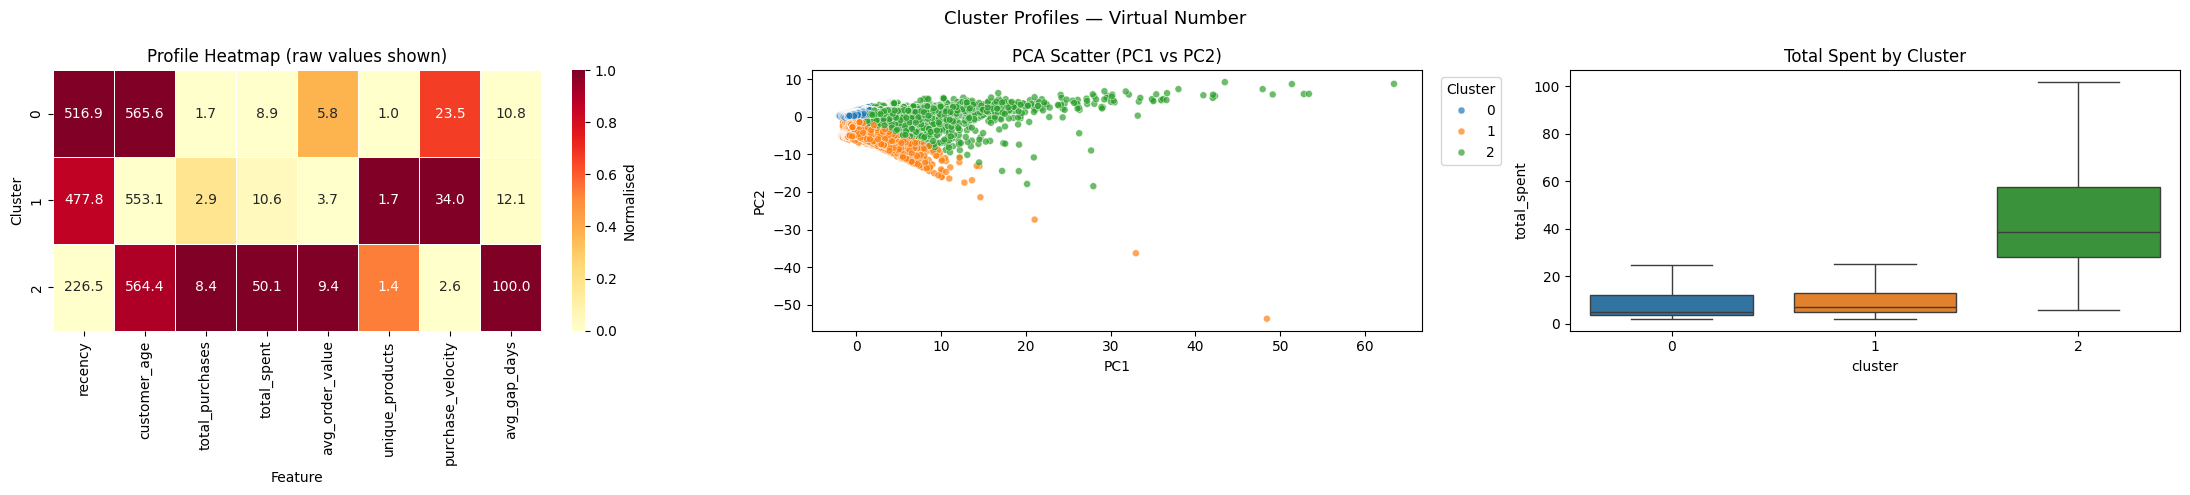

         recency  customer_age  total_purchases  total_spent  avg_order_value  unique_products  purchase_velocity  avg_gap_days
cluster                                                                                                                        
0         516.91        565.60             1.71         8.89             5.82             1.01              23.51         10.84
1         477.84        553.07             2.86        10.60             3.71             1.69              33.99         12.05
2         226.49        564.41             8.37        50.13             9.45             1.37               2.56        100.04



In [20]:
plot_cluster_profile(virtual_clustered, 'Virtual Number')

In [21]:
virtual_clustered.groupby('cluster').mean(numeric_only=True)

,id_client,recency,customer_age,total_purchases,total_spent,avg_order_value,std_order_value,unique_products,purchase_velocity,avg_gap_days,spend_eu_bundle,spend_local_calling_plan,spend_phone_number,share_eu_bundle,share_local_calling_plan,share_phone_number,PC1,PC2
cluster,,,,,,,,,,,,,,,,,,
0,1.812394e+07,516.913431,565.598782,1.714237,8.894231,5.821940,0.236527,1.013999,23.510922,10.844424,0.000000,0.027998,8.866232,0.000000,0.001677,0.998323,-0.673812,0.597271
1,1.829955e+07,477.835496,553.074604,2.863897,10.601080,3.714831,1.881216,1.690826,33.987648,12.054975,0.037318,4.411164,6.152598,0.002498,0.522534,0.474968,-0.021409,-3.180768
2,1.814044e+07,226.486847,564.414480,8.367870,50.125407,9.445431,3.915771,1.367150,2.558970,100.041034,0.034023,1.712522,48.378863,0.000499,0.039988,0.959513,3.354437,0.484906


| Cluster | Segment Name                | Value       | Behavior                                 | Strategy                  |
| ------- | --------------------------- | ----------- | ---------------------------------------- | ------------------------- |
| 0       | Light Occasional Users     | Low         | Low purchases, low spend | Activation campaign      |
| 1       | Mid-Tier Phone Plan Holders      | Medium      | Moderate     | Upsell to EU bundle or international calling add-ons  |
| 2       | High-Spend Power Users  | Highest         | Highest spend, highest purchase           | Enterprise/business plan pitch |

In [22]:
# Maps numeric cluster labels to descriptive names for easier interpretation and previews the updated dataset with cluster names included
virtual_cluster_names = {
    0: 'Virtual - Light Occasional Users',
    1: 'Virtual - Mid-Tier Phone Plan Holders',
    2: 'Virtual - High-Spend Power Users'
}

virtual_clustered['cluster_name'] = virtual_clustered['cluster'].map(virtual_cluster_names)
virtual_clustered.head()

,id_client,recency,customer_age,total_purchases,total_spent,avg_order_value,std_order_value,unique_products,purchase_velocity,avg_gap_days,spend_eu_bundle,spend_local_calling_plan,spend_phone_number,share_eu_bundle,share_local_calling_plan,share_phone_number,cluster,PC1,PC2,cluster_name
0,15735847,730,730,1,6.00,6.00,0.000000,1,30.000000,0.0,0.0,0.0,6.00,0.0,0.000000,1.000000,0,-1.462932,0.749592,Virtual - Light Occasional Users
1,15735879,730,730,1,3.49,3.49,0.000000,1,30.000000,0.0,0.0,0.0,3.49,0.0,0.000000,1.000000,0,-1.625322,0.647462,Virtual - Light Occasional Users
2,15735902,730,730,1,17.99,17.99,0.000000,1,30.000000,0.0,0.0,0.0,17.99,0.0,0.000000,1.000000,0,-0.687211,1.237456,Virtual - Light Occasional Users
3,15735905,730,730,2,6.00,3.00,1.414214,2,60.000000,0.0,0.0,2.0,4.00,0.0,0.333333,0.666667,1,-1.214478,-2.190736,Virtual - Mid-Tier Phone Plan Holders
4,15735933,414,730,2,6.98,3.49,0.000000,1,1.935484,31.0,0.0,0.0,6.98,0.0,0.000000,1.000000,0,-0.330745,0.740736,Virtual - Light Occasional Users


In [23]:
virtual_clustered.to_csv('Client_Virtual_Clustered.csv', index=False)
print("Saved: Client_Virtual_Clustered.csv")

Saved: Client_Virtual_Clustered.csv


---
# 6. All Datasets — Client Clustering

In [24]:
def prepare_df(df, prefix):
    # Adds a flag for dataset type.
    df[f'has_{prefix}'] = 1
    
    # Creates one-hot encoded segment features from cluster names "pd.get_dummies".
    segments = pd.get_dummies(df['cluster_name'], prefix='segment')
    df = pd.concat([df, segments], axis=1)

    # Renames key metrics with a prefix per dataset.
    cols_to_rename = {
        'total_spent': f'spend_{prefix}',
        'total_purchases': f'purchases_{prefix}',
        'recency': f'recency_{prefix}',
        'cluster_name': f'segment_{prefix}'
    }
    return df.rename(columns=cols_to_rename)

# Prepare separated, standardized tables for calls, eSIM, and virtual user groups.
calls_prep = prepare_df(calls_clustered, 'calls')
esim_prep = prepare_df(esim_clustered, 'esim')
virtual_prep = prepare_df(virtual_clustered, 'virtual')

In [25]:
df_final = calls_prep.merge(esim_prep, on='id_client', how='outer') \
                     .merge(virtual_prep, on='id_client', how='outer')

In [26]:
# This function checks which services a client uses and combines them into one readable string.
def get_prod_string(row):
    prods = []
    
    # Check for active status (1) in each service category and add the name to our list.
    if row.get('has_calls') == 1: prods.append('Calls')
    if row.get('has_esim') == 1: prods.append('Data eSIM')
    if row.get('has_virtual') == 1: prods.append('Virtual Number')
    
    # Combine the list items into a single string separated by commas (e.g., "Calls, Data eSIM")
    return ", ".join(prods)

# Apply the function row-by-row (axis=1) to create a new summary column.
df_final['product_group'] = df_final.apply(get_prod_string, axis=1)

# Global Recency (The most recent activity).
df_final['recency'] = df_final[['recency_calls', 'recency_esim', 'recency_virtual']].min(axis=1)

# Total Purchase Count.
df_final['total_purchase_count'] = df_final[['purchases_calls', 'purchases_esim', 'purchases_virtual']].sum(axis=1)

# Total Spend.
df_final['total_spend'] = df_final[['spend_calls', 'spend_esim', 'spend_virtual']].sum(axis=1)

In [27]:
all_segment_binary_cols = [c for c in df_final.columns if c.startswith('segment_') and not c.endswith(('_calls', '_esim', '_virtual'))]

final_cols = [
    'id_client', 
    'has_calls', 'has_esim', 'has_virtual', 
    'product_group',                     
    'recency', 'total_purchase_count', 'total_spend'   
] + all_segment_binary_cols               

df_final = df_final[final_cols]

In [28]:
binary_cols = [c for c in df_final.columns if c.startswith('has_') or c.startswith('segment_')]

df_final[binary_cols] = df_final[binary_cols].fillna(0).astype(int)

In [29]:
df_final = pd.merge(
    df_final, 
    df[['id_client', 'User Country', 'platform', 'language', 'User phone number']]
        .drop_duplicates(subset=['id_client']), on='id_client', how='left')

In [30]:
df_final

,id_client,has_calls,has_esim,has_virtual,product_group,recency,total_purchase_count,total_spend,segment_Calls - Infrequent Casual Users,segment_Calls - Regular Calling Offer Users,segment_eSIM - Dormant Local Data Users,segment_eSIM - High-Value Bundle Subscribers,segment_eSIM - High-Velocity Light Spenders,segment_Virtual - High-Spend Power Users,segment_Virtual - Light Occasional Users,segment_Virtual - Mid-Tier Phone Plan Holders,User Country,platform,language,User phone number
0,15735847,0,0,1,Virtual Number,730.0,1.0,6.00,0,0,0,0,0,0,1,0,Pakistan,iOS,english,923126335257
1,15735879,0,0,1,Virtual Number,730.0,1.0,3.49,0,0,0,0,0,0,1,0,Indonesia,Android,english,6281337725179
2,15735902,0,0,1,Virtual Number,730.0,1.0,17.99,0,0,0,0,0,0,1,0,UK,Android,english,447450985551
3,15735905,0,1,1,"Data eSIM, Virtual Number",730.0,3.0,15.00,0,0,0,0,1,0,0,1,KSA,Android,arabic,966572696109
4,15735920,1,0,0,Calls,730.0,1.0,2.00,1,0,0,0,0,0,0,0,Senegal,Android,french,221761210221
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
278169,20563132,0,0,1,Virtual Number,352.0,2.0,6.98,0,0,0,0,0,0,1,0,Switzerland,Android,french,41774746974
278170,20563135,0,0,1,Virtual Number,361.0,1.0,3.49,0,0,0,0,0,0,1,0,Bolivia,Android,spanish,59176155268
278171,20563151,0,0,1,Virtual Number,66.0,1.0,3.49,0,0,0,0,0,0,1,0,Nigeria,Android,english,2348101277751
278172,20563159,1,0,0,Calls,49.0,7.0,26.00,0,1,0,0,0,0,0,0,Pakistan,iOS,english,923364680223


In [31]:
df_final.isna().sum()

id_client                                          0
has_calls                                          0
has_esim                                           0
has_virtual                                        0
product_group                                      0
recency                                            0
total_purchase_count                               0
total_spend                                        0
segment_Calls - Infrequent Casual Users            0
segment_Calls - Regular Calling Offer Users        0
segment_eSIM - Dormant Local Data Users            0
segment_eSIM - High-Value Bundle Subscribers       0
segment_eSIM - High-Velocity Light Spenders        0
segment_Virtual - High-Spend Power Users           0
segment_Virtual - Light Occasional Users           0
segment_Virtual - Mid-Tier Phone Plan Holders      0
User Country                                     172
platform                                           0
language                                      

# 7. Reactivation Prediction Pipeline

In [32]:
DORMANT_DAYS   = 90

REFERENCE_DATE = df['purchase_date'].max().normalize()

# tx : transaction baised data
# cl : client baised data

tx = df.copy()
tx['purchase_date'] = pd.to_datetime(tx['purchase_date'])
tx = tx.sort_values(['id_client', 'purchase_date']).reset_index(drop=True)

# Encode whether each transaction was a renewal (1) or a new purchase (0).
tx['is_renewal'] = (tx['renewal_status'].str.lower().str.strip() == 'renewed').astype(int)

cl = df_final.copy()

print(f"Transactions : {len(tx):,}")
print(f"Clients      : {tx['id_client'].nunique():,}")
print(f"Date range   : {tx['purchase_date'].min().date()} \u2192 {tx['purchase_date'].max().date()}")

Transactions : 826,859
Clients      : 278,174
Date range   : 2024-01-01 → 2025-12-31


In [33]:
# For every transaction; .shift(1) looks at the previous transaction for the same client.
tx['prev_date'] = tx.groupby('id_client')['purchase_date'].shift(1)

# gap_days is the number of days since their last purchase.
tx['gap_days']  = (tx['purchase_date'] - tx['prev_date']).dt.days

# Positive training examples (gap >= threshold, label = 1), they reactivated.
reactivation_events = tx[tx['gap_days'] >= DORMANT_DAYS].copy()

# Currently dormant: last purchase >= DORMANT_DAYS ago
last_tx = (
    tx.groupby('id_client')['purchase_date']
    .max().reset_index()
    .rename(columns={'purchase_date': 'last_purchase_date'})
)

# Negative training candidates and our scoring targets (last purchase >= DORMANT_DAYS, label = 0), they are dormant.
last_tx['days_since_last'] = (REFERENCE_DATE - last_tx['last_purchase_date']).dt.days
currently_dormant = last_tx[last_tx['days_since_last'] >= DORMANT_DAYS].copy()

print(f"Historical reactivation episodes : {len(reactivation_events):,}")
print(f"Currently dormant clients        : {len(currently_dormant):,}")

Historical reactivation episodes : 49,598
Currently dormant clients        : 256,203


In [34]:
# Create a unique list of all products (lowercase) to use for one-hot encoding/flags.
ALL_PRODUCTS = tx['product_type'].dropna().str.lower().unique().tolist()

def vectorized_features(tx_subset, cutoff_map):
    # Merge transactions with their specific cutoff dates based on client ID.
    df_ = tx_subset.merge(
        cutoff_map.rename('cutoff').reset_index(), on='id_client', how='inner'
    )

    # CRITICAL: Filter out any data that happened AFTER the cutoff date.
    # This prevents "Data Leakage" (using future info to predict the past).
    df_ = df_[df_['purchase_date'] < df_['cutoff']].copy()
    if df_.empty:
        return pd.DataFrame()

    # Calculate time-based helper columns.
    df_['days_to_cutoff'] = (df_['cutoff'] - df_['purchase_date']).dt.days
    df_['in_last_30d']  = df_['days_to_cutoff'] <= 30  # Flag for recent activity.
    df_['product_lower']  = df_['product_type'].str.lower()

    grp = df_.groupby('id_client')

    base = pd.DataFrame({
        # Straightforward aggregations. spend_std is filled with 0 for single-purchase clients 
        # (std is undefined with only one value).
        'frequency' : grp['purchase_date'].count(),
        'total_spend' : grp['price'].sum(),
        'avg_spend' : grp['price'].mean(),
        'max_spend' : grp['price'].max(),
        'spend_std' : grp['price'].std().fillna(0),
        
        # This measures how active the client was right before they disappeared.
        'spend_last_30d' : grp.apply(lambda g: g.loc[g['in_last_30d'], 'price'].sum()),
        
        # Tenure: Days between first and last purchase (minimum 1 day so you don't divide by 0).
        'tenure_days' : grp['purchase_date'].apply(
                                    lambda d: max((d.max() - d.min()).days, 1)),
        
        # Number of different products tried.
        'product_diversity' : grp['product_type'].nunique(),
        
        # % of purchases that were renewals.
        # A high renewal rate suggests habitual, subscription-like behavior — such clients are more likely to come back.
        'renewal_rate' : grp['is_renewal'].mean(),
        
        # Count how many times the user disappeared for longer than the 'DORMANT_DAYS' threshold.
        # Past reactivation behavior predicts future reactivation behavior.
        'prior_reactivations' : grp['gap_days'].apply(
                                    lambda g: (g.fillna(0) >= DORMANT_DAYS).sum()),
        
        # Find the product they bought most often.
        'top_product' : grp['product_lower'].apply(
                                    lambda s: s.value_counts().idxmax() if len(s) > 0 else 'unknown'),
    })

    # This approximates the average gap as tenure / (purchases - 1). 
    # The .clip(lower=1) handles single-purchase clients.
    base['avg_gap_days'] = base['tenure_days'] / (base['frequency'] - 1).clip(lower=1)
    
    # This answers: "Were they spending more or less than usual right before disappearing?"
    # Positive = spending more lately; Negative = spending less lately.
    base['spend_trend']  = ( base['spend_last_30d']- (base['total_spend'] - base['spend_last_30d'])
        / (base['tenure_days'] - 30).clip(lower=1) * 30)
    
    # It works like this:
    # total_spend - spend_last_30d = spend in everything before the last 30 days.
    # / (tenure_days - 30) = daily average rate during that earlier period.
    # * 30 = what you'd expect in 30 days at that historical rate.
    # Then: spend_last_30d - expected = positive means they were accelerating, negative means they were declining.


    # Product presence flags & top-product one-hot (single pass)
    for prod in ALL_PRODUCTS:
        mask = df_[df_['product_lower'] == prod].groupby('id_client').size() > 0
        base[f'has_{prod}'] = mask.reindex(base.index, fill_value=False).astype(int)
        base[f'top_product_{prod}'] = (base['top_product'] == prod).astype(int)

    base.drop(columns=['top_product'], inplace=True)
    return base.reset_index()

print("vectorized_features() defined.")

vectorized_features() defined.


In [35]:
# Positive: historical reactivations (cutoff = last purchase before the gap)
pos_cutoff = reactivation_events.drop_duplicates('id_client').set_index('id_client')['prev_date']
pos_features = vectorized_features(tx, pos_cutoff)
pos_features['reactivated'] = 1
pos_features['gap_start_date'] = pos_features['id_client'].map(pos_cutoff)

# Negative: dormant clients who never came back
never_came_back = currently_dormant[
    ~currently_dormant['id_client'].isin(reactivation_events['id_client'])
].copy()
neg_cutoff   = never_came_back.set_index('id_client')['last_purchase_date']
neg_features = vectorized_features(tx, neg_cutoff)
neg_features['reactivated']    = 0
neg_features['gap_start_date'] = neg_features['id_client'].map(neg_cutoff)

# Combine & join segment flags from df_final
segment_cols = [c for c in cl.columns if c.startswith('segment_')]
cl_segments = cl[['id_client'] + segment_cols].drop_duplicates('id_client')

episodes_df = (
    pd.concat([pos_features, neg_features], ignore_index=True)
    .fillna(0)
    .merge(cl_segments, on='id_client', how='left')
)
episodes_df[segment_cols] = episodes_df[segment_cols].fillna(0)

print(f"Labeled episodes : {len(episodes_df):,}")
print(f"  Reactivated (1): {episodes_df['reactivated'].sum():,}  ({episodes_df['reactivated'].mean()*100:.1f}%)")
print(f"  Dormant     (0): {(episodes_df['reactivated']==0).sum():,}")

Labeled episodes : 92,053
  Reactivated (1): 19,845  (21.6%)
  Dormant     (0): 72,208


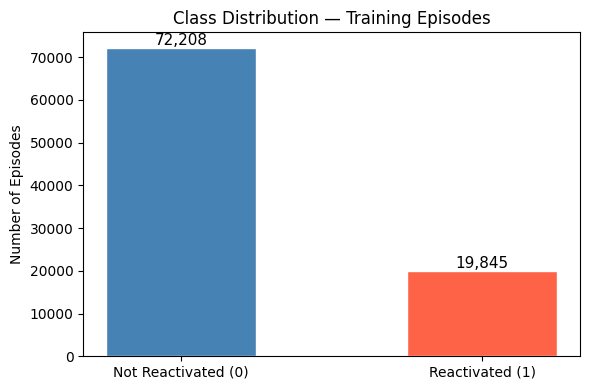

In [47]:
class_counts = pd.Series({
    'Not Reactivated (0)': (y_train == 0).sum() + (y_test == 0).sum(),
    'Reactivated (1)':     (y_train == 1).sum() + (y_test == 1).sum()
})

plt.figure(figsize=(6, 4))
bars = plt.bar(class_counts.index, class_counts.values, 
               color=['steelblue', 'tomato'], edgecolor='white', width=0.5)
for bar, val in zip(bars, class_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{val:,}', ha='center', va='bottom', fontsize=11)
plt.title('Class Distribution — Training Episodes')
plt.ylabel('Number of Episodes')
plt.tight_layout()
plt.show()

In [36]:
EXCLUDE = {'id_client', 'reactivated', 'gap_start_date'}
feature_cols = [c for c in episodes_df.columns if c not in EXCLUDE]

X = episodes_df[feature_cols]
y = episodes_df['reactivated']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=8,
    min_samples_split=50, min_samples_leaf=25,
    class_weight='balanced', random_state=42, n_jobs=-1
)

# n_estimators=200 : 200 decision trees, averaged together
# max_depth=8 : trees can't grow deeper than 8 levels (prevents overfitting)
# min_samples_split=50, min_samples_leaf=25 : a node must have 50 samples to split, and leaves must have at least 25.
# class_weight='balanced' : automatically upweights the minority class. Critical here since reactivations are likely rare

rf_model.fit(X_train, y_train)

y_pred       = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]
auc_score    = roc_auc_score(y_test, y_pred_proba)

print(classification_report(y_test, y_pred, target_names=['Stayed Dormant', 'Reactivated']))
print(f"AUC-ROC: {auc_score:.4f}  (good range: 0.65\u20130.85)")

cm = confusion_matrix(y_test, y_pred)
print(f"TN={cm[0,0]:,}  FP={cm[0,1]:,}  FN={cm[1,0]:,}  TP={cm[1,1]:,}")

                precision    recall  f1-score   support

Stayed Dormant       0.93      0.82      0.87     21662
   Reactivated       0.55      0.77      0.64      5954

      accuracy                           0.81     27616
     macro avg       0.74      0.80      0.76     27616
  weighted avg       0.85      0.81      0.82     27616

AUC-ROC: 0.8130  (good range: 0.65–0.85)
TN=17,848  FP=3,814  FN=1,346  TP=4,608


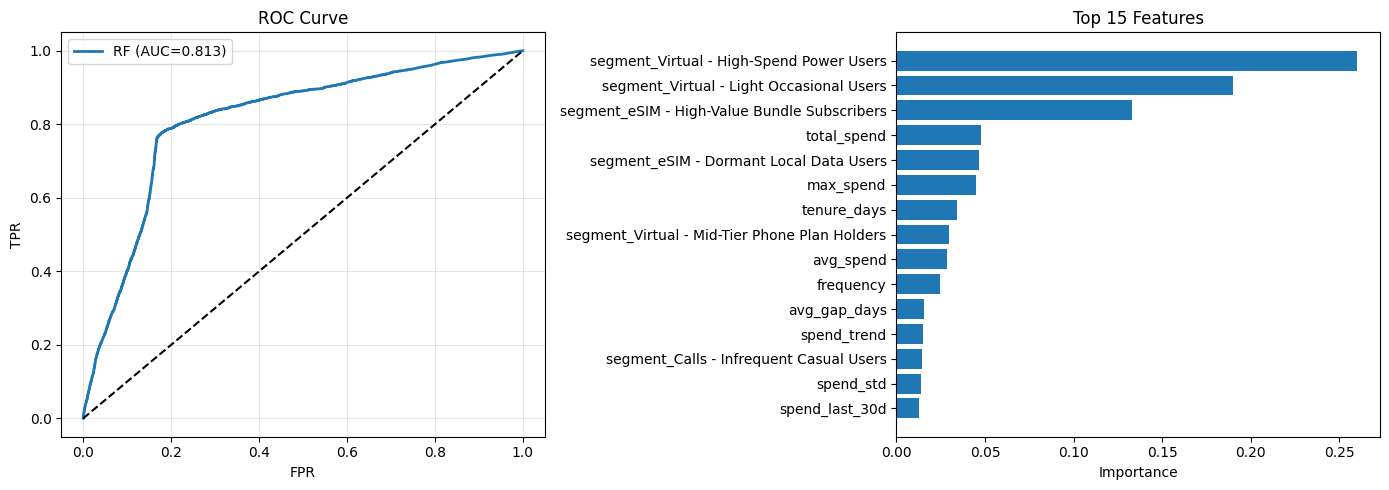

                                      feature  importance
     segment_Virtual - High-Spend Power Users    0.259921
     segment_Virtual - Light Occasional Users    0.190074
 segment_eSIM - High-Value Bundle Subscribers    0.132693
                                  total_spend    0.047954
      segment_eSIM - Dormant Local Data Users    0.046751
                                    max_spend    0.045083
                                  tenure_days    0.034275
segment_Virtual - Mid-Tier Phone Plan Holders    0.029780
                                    avg_spend    0.028479
                                    frequency    0.024364
                                 avg_gap_days    0.015402
                                  spend_trend    0.015144
      segment_Calls - Infrequent Casual Users    0.014650
                                    spend_std    0.013813
                               spend_last_30d    0.012830


In [37]:
fi = (pd.DataFrame({'feature': feature_cols, 'importance': rf_model.feature_importances_})
        .sort_values('importance', ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[0].plot(fpr, tpr, label=f'RF (AUC={auc_score:.3f})', linewidth=2)
axes[0].plot([0,1],[0,1],'k--'); axes[0].set(xlabel='FPR', ylabel='TPR', title='ROC Curve')
axes[0].legend(); axes[0].grid(alpha=0.3)

top15 = fi.head(15)
axes[1].barh(range(len(top15)), top15['importance'])
axes[1].set_yticks(range(len(top15))); axes[1].set_yticklabels(top15['feature'])
axes[1].set(xlabel='Importance', title='Top 15 Features'); axes[1].invert_yaxis()

plt.tight_layout(); plt.show()
print(fi.head(15).to_string(index=False))

In [38]:
# Score all currently dormant clients
all_dormant_cutoff = currently_dormant.set_index('id_client')['last_purchase_date']
scoring_df = vectorized_features(tx, all_dormant_cutoff).fillna(0)

scoring_df = (
    scoring_df
    .merge(currently_dormant[['id_client','last_purchase_date','days_since_last']], on='id_client', how='left')
    .merge(cl_segments, on='id_client', how='left')
)
scoring_df[segment_cols] = scoring_df[segment_cols].fillna(0)

# Align columns to training feature set
for col in feature_cols:
    if col not in scoring_df.columns:
        scoring_df[col] = 0

scoring_df['reactivation_probability'] = rf_model.predict_proba(scoring_df[feature_cols])[:, 1]
scoring_df['reactivation_score']       = (scoring_df['reactivation_probability'] * 100).round(2)

print(f"Clients with a reactivation score: {len(scoring_df):,}")
scoring_df[['id_client','reactivation_probability','reactivation_score']].head()


Clients with a reactivation score: 96,566


,id_client,reactivation_probability,reactivation_score
0,15735933,0.297321,29.73
1,15735986,0.398756,39.88
2,15736016,0.663508,66.35
3,15736044,0.588779,58.88
4,15736082,0.297321,29.73


# HIGH / MEDIUM / LOW buckets — percentile-based

Instead of fixed thresholds (`>=80` / `50-80` / `<50`), buckets are defined as percentiles of the scored population. Top 20% = HIGH, next 30% = MEDIUM, bottom 50% = LOW. This is the standard approach in propensity / reactivation modelling (decile / quintile analysis): bucket sizes don't depend on the model's absolute probability range, so retraining can't accidentally empty out a bucket the way the fixed `>=80` cutoff did here (model max is ~0.73).

Cutoff values are computed once from the current scored population and printed below — those are the numbers the dashboard should also use to colour the reactivation badge.

In [39]:
# Bucket cutoffs as percentile ranks of the scored population.
# top 20% = HIGH, next 30% = MEDIUM, bottom 50% = LOW.
BUCKET_HIGH_PCTILE = 0.80
BUCKET_MED_PCTILE  = 0.50

# Percentile cutoffs from the scored population.
hi_cutoff = scoring_df['reactivation_score'].quantile(BUCKET_HIGH_PCTILE)
md_cutoff = scoring_df['reactivation_score'].quantile(BUCKET_MED_PCTILE)

high   = scoring_df[scoring_df['reactivation_score'] >= hi_cutoff]
medium = scoring_df[(scoring_df['reactivation_score'] >= md_cutoff)
                    & (scoring_df['reactivation_score'] < hi_cutoff)]
low    = scoring_df[scoring_df['reactivation_score'] <  md_cutoff]

print(f"Bucket cutoffs (percentile-based): HIGH score >= {hi_cutoff:.2f}, MEDIUM score >= {md_cutoff:.2f}")
print(f"  HIGH   (top 20%):    {len(high):,} customers")
print(f"  MEDIUM (next 30%):   {len(medium):,} customers")
print(f"  LOW    (bottom 50%): {len(low):,} customers")

# Tag each scored row with its bucket so the saved CSV has a ready-to-use
# label column. Dashboard can either use this directly or re-derive from the
# cutoffs at display time.
def _bucket(s):
    if s >= hi_cutoff: return 'HIGH'
    if s >= md_cutoff: return 'MEDIUM'
    return 'LOW'
scoring_df['bucket'] = scoring_df['reactivation_score'].apply(_bucket)

# Segment breakdown — same shape as the original cell, with the new buckets
seg_rows = []
for col in segment_cols:
    seg = scoring_df[scoring_df[col] == 1]
    if len(seg) > 50:
        seg_rows.append({
            'Segment'    : col.replace('segment_',''),
            'Customers'  : len(seg),
            'Avg Score'  : round(seg['reactivation_score'].mean(), 1),
            'Avg Spend'  : round(seg['total_spend'].mean(), 2),
            'High Pri.'  : (seg['reactivation_score'] >= hi_cutoff).sum(),
        })
if seg_rows:
    print()
    print(pd.DataFrame(seg_rows).sort_values('Avg Score', ascending=False).to_string(index=False))

Bucket cutoffs (percentile-based): HIGH score >= 64.21, MEDIUM score >= 38.45
  HIGH   (top 20%):    19,335 customers
  MEDIUM (next 30%):   28,953 customers
  LOW    (bottom 50%): 48,278 customers

                              Segment  Customers  Avg Score  Avg Spend  High Pri.
     Virtual - High-Spend Power Users      16354       65.7      49.56      12353
 eSIM - High-Value Bundle Subscribers      10421       65.1      30.52       7161
  eSIM - High-Velocity Light Spenders       2268       49.1      32.48        411
      Calls - Infrequent Casual Users      21467       47.6      29.71       4244
  Calls - Regular Calling Offer Users       6768       47.4      29.54       1296
Virtual - Mid-Tier Phone Plan Holders      13716       41.9      16.78          7
      eSIM - Dormant Local Data Users      10563       40.3      17.02        414
     Virtual - Light Occasional Users      47896       34.2      11.31          0


In [40]:
out_cols = (['id_client','last_purchase_date','days_since_last',
             'reactivation_score','reactivation_probability',
             'frequency','total_spend','avg_spend','tenure_days',
             'product_diversity','renewal_rate','prior_reactivations',
             'has_calls','has_esim','has_virtual'] + segment_cols)
out_cols = [c for c in out_cols if c in scoring_df.columns]

(scoring_df[out_cols]
    .sort_values('reactivation_score', ascending=False)
    .to_csv('dormant_customers_scored.csv', index=False))

scoring_df[out_cols].nlargest(100, 'reactivation_score').to_csv('top_100_reactivation_targets.csv', index=False)
df_final.to_csv('df_final_with_reactivation.csv', index=False)
joblib.dump(rf_model, 'reactivation_model.pkl')

print("dormant_customers_scored.csv")
print("top_100_reactivation_targets.csv")
print("df_final_with_reactivation.csv  ← df_final now includes reactivation_probability")
print("reactivation_model.pkl")
print()
print("=== TOP 10 TARGETS ===")
print(scoring_df[out_cols].nlargest(10, 'reactivation_score').to_string(index=False))

dormant_customers_scored.csv
top_100_reactivation_targets.csv
df_final_with_reactivation.csv  ← df_final now includes reactivation_probability
reactivation_model.pkl

=== TOP 10 TARGETS ===
 id_client last_purchase_date  days_since_last  reactivation_score  reactivation_probability  frequency  total_spend  avg_spend  tenure_days  product_diversity  renewal_rate  prior_reactivations  segment_Calls - Infrequent Casual Users  segment_Calls - Regular Calling Offer Users  segment_eSIM - Dormant Local Data Users  segment_eSIM - High-Value Bundle Subscribers  segment_eSIM - High-Velocity Light Spenders  segment_Virtual - High-Spend Power Users  segment_Virtual - Light Occasional Users  segment_Virtual - Mid-Tier Phone Plan Holders
  16059892         2025-01-20              345               75.14                  0.751424          6    59.980000   9.996667          366                  4           0.0                    1                                        1                               

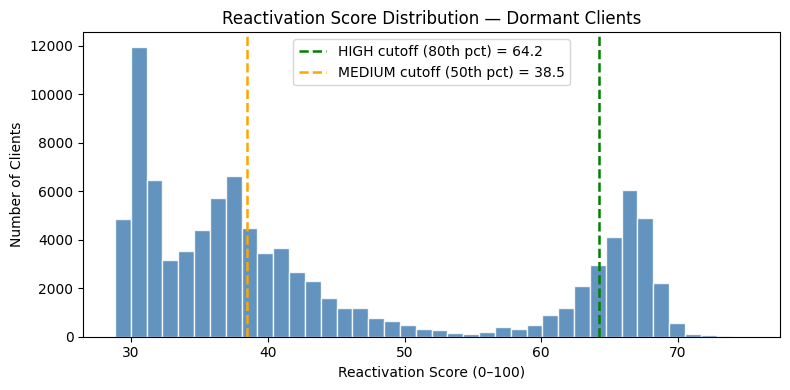

In [48]:
high_cutoff = scoring_df['reactivation_score'].quantile(0.80)
med_cutoff  = scoring_df['reactivation_score'].quantile(0.50)

plt.figure(figsize=(8, 4))
plt.hist(scoring_df['reactivation_score'], bins=40, 
         color='steelblue', edgecolor='white', alpha=0.85)
plt.axvline(high_cutoff, color='green',  linestyle='--', linewidth=1.8,
            label=f'HIGH cutoff (80th pct) = {high_cutoff:.1f}')
plt.axvline(med_cutoff,  color='orange', linestyle='--', linewidth=1.8,
            label=f'MEDIUM cutoff (50th pct) = {med_cutoff:.1f}')
plt.title('Reactivation Score Distribution — Dormant Clients')
plt.xlabel('Reactivation Score (0–100)')
plt.ylabel('Number of Clients')
plt.legend()
plt.tight_layout()
plt.show()

---

In [41]:
import math

def plot_original_features(clustered_df, group_name, top_n=8, palette='tab10'):
    feature_cols = [
        c for c in clustered_df.columns
        if c not in {'id_client', 'cluster', 'cluster_name', 'PC1', 'PC2'}
        and clustered_df[c].dtype in [np.float64, np.int64, np.float32, np.int32]
    ]

    # Rank features by how much they vary across cluster means (discriminability)
    cluster_means = clustered_df.groupby('cluster')[feature_cols].mean()
    feature_range = (cluster_means.max() - cluster_means.min())
    top_features  = feature_range.nlargest(top_n).index.tolist()

    n_cols = 4
    n_rows = math.ceil(top_n / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(n_cols * 4.5, n_rows * 3.5))
    axes = axes.flatten()
    fig.suptitle(f'Cluster Distributions in Original Feature Space — {group_name}',
                 fontsize=14, fontweight='bold', y=1.01)

    clusters      = sorted(clustered_df['cluster'].unique())
    colors        = plt.get_cmap(palette).colors
    has_names     = 'cluster_name' in clustered_df.columns

    for ax_i, feat in enumerate(top_features):
        ax = axes[ax_i]
        for c in clusters:
            subset = clustered_df.loc[clustered_df['cluster'] == c, feat].dropna()
            label  = (clustered_df.loc[clustered_df['cluster'] == c, 'cluster_name'].iloc[0]
                      if has_names else f'Cluster {c}')
            color  = colors[c % len(colors)]

            # KDE (only meaningful with >1 unique value)
            if subset.nunique() > 1:
                subset.plot.kde(ax=ax, label=label, color=color, linewidth=2)
            else:
                ax.axvline(subset.iloc[0], color=color, linewidth=2, label=label)

            # Rug plot for raw data feel
            ax.plot(subset, np.zeros(len(subset)) - 0.01 * ax_i,
                    '|', color=color, alpha=0.3, markersize=6)

        ax.set_title(feat.replace('_', ' ').title(), fontsize=10)
        ax.set_xlabel('')
        ax.set_ylabel('Density')
        ax.grid(axis='y', alpha=0.3)
        ax.legend(fontsize=7, loc='upper right',
                  title='Cluster', title_fontsize=7)

    # Hide unused axes
    for ax in axes[top_n:]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()
    

In [42]:
def plot_pairwise_scatter(clustered_df, group_name, top_n=4, palette='tab10'):

    feature_cols = [
        c for c in clustered_df.columns
        if c not in {'id_client', 'cluster', 'cluster_name', 'PC1', 'PC2'}
        and clustered_df[c].dtype in [np.float64, np.int64, np.float32, np.int32]
    ]

    cluster_means = clustered_df.groupby('cluster')[feature_cols].mean()
    feature_range = (cluster_means.max() - cluster_means.min())
    top_features  = feature_range.nlargest(top_n).index.tolist()

    plot_df = clustered_df[top_features + ['cluster']].copy()

    clusters = sorted(plot_df['cluster'].unique())
    colors   = plt.get_cmap(palette).colors
    color_map = {c: colors[c % len(colors)] for c in clusters}

    n = len(top_features)
    fig, axes = plt.subplots(n, n, figsize=(n * 3, n * 3))
    fig.suptitle(f'Pairwise Feature Scatter — {group_name}',
                 fontsize=13, fontweight='bold', y=1.01)

    for row_i, feat_y in enumerate(top_features):
        for col_i, feat_x in enumerate(top_features):
            ax = axes[row_i][col_i]
            if row_i == col_i:
                # Diagonal: KDE per cluster
                for c in clusters:
                    sub = plot_df.loc[plot_df['cluster'] == c, feat_x].dropna()
                    if sub.nunique() > 1:
                        sub.plot.kde(ax=ax, color=color_map[c],
                                     linewidth=2, label=f'C{c}')
                ax.set_xlabel(feat_x.replace('_', ' ').title(), fontsize=8)
                ax.set_ylabel('Density', fontsize=7)
            else:
                # Off-diagonal: scatter
                for c in clusters:
                    mask = plot_df['cluster'] == c
                    ax.scatter(plot_df.loc[mask, feat_x],
                               plot_df.loc[mask, feat_y],
                               color=color_map[c], alpha=0.35,
                               s=12, label=f'C{c}')
                ax.set_xlabel(feat_x.replace('_', ' ').title(), fontsize=8)
                ax.set_ylabel(feat_y.replace('_', ' ').title(), fontsize=8)
            ax.grid(alpha=0.2)

    # Shared legend
    handles = [plt.Line2D([0], [0], marker='o', color='w',
                           markerfacecolor=color_map[c], markersize=8,
                           label=f'Cluster {c}')
               for c in clusters]
    fig.legend(handles=handles, loc='lower center',
               ncol=len(clusters), bbox_to_anchor=(0.5, -0.02),
               title='Cluster', fontsize=9)

    plt.tight_layout()
    plt.show()

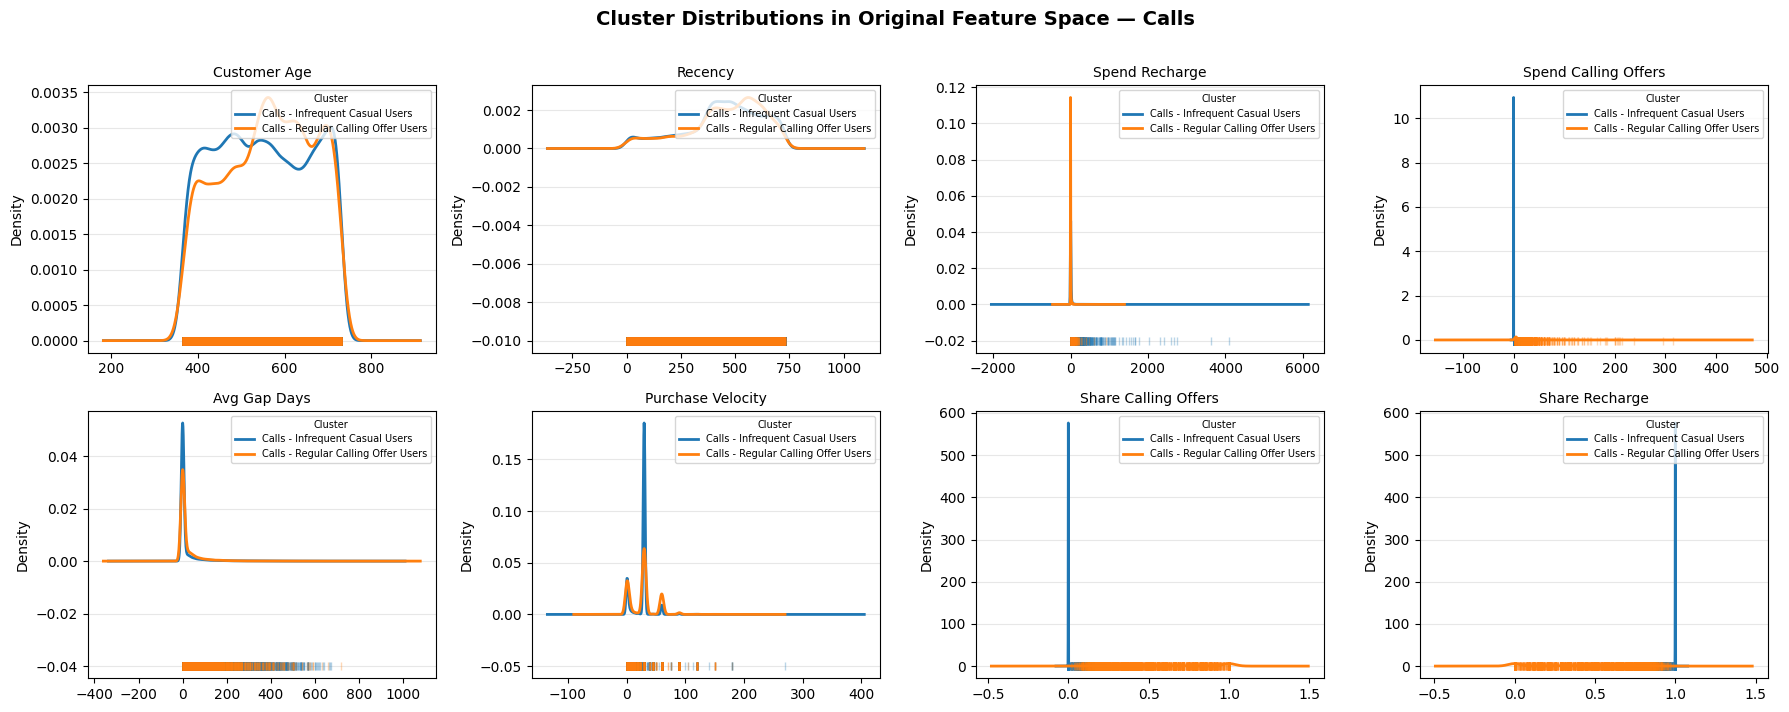

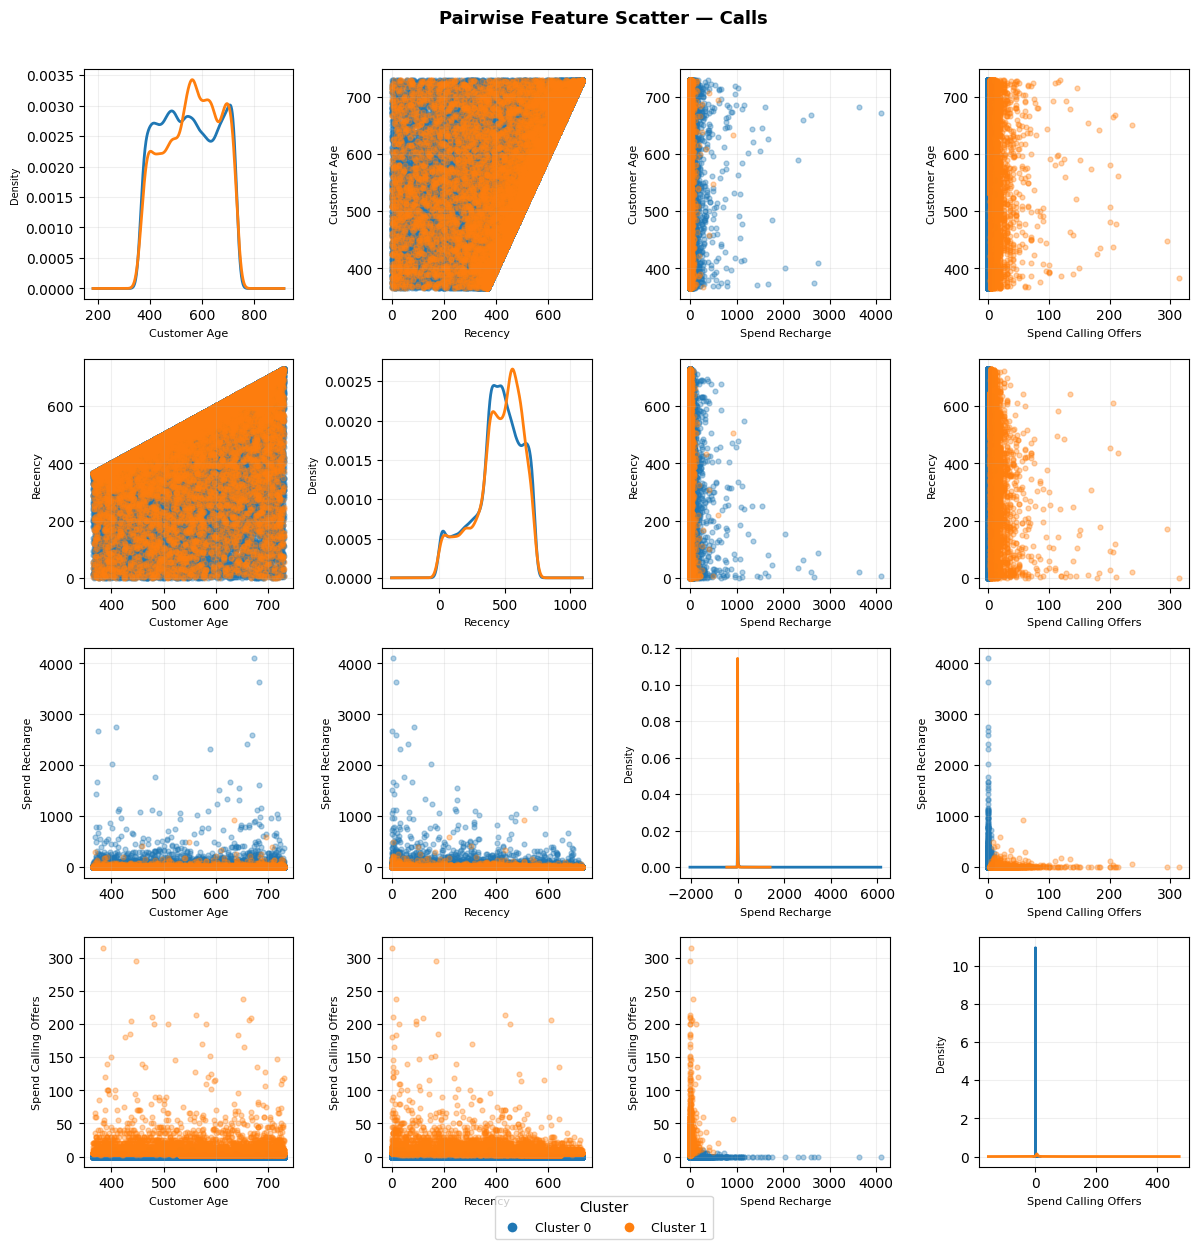

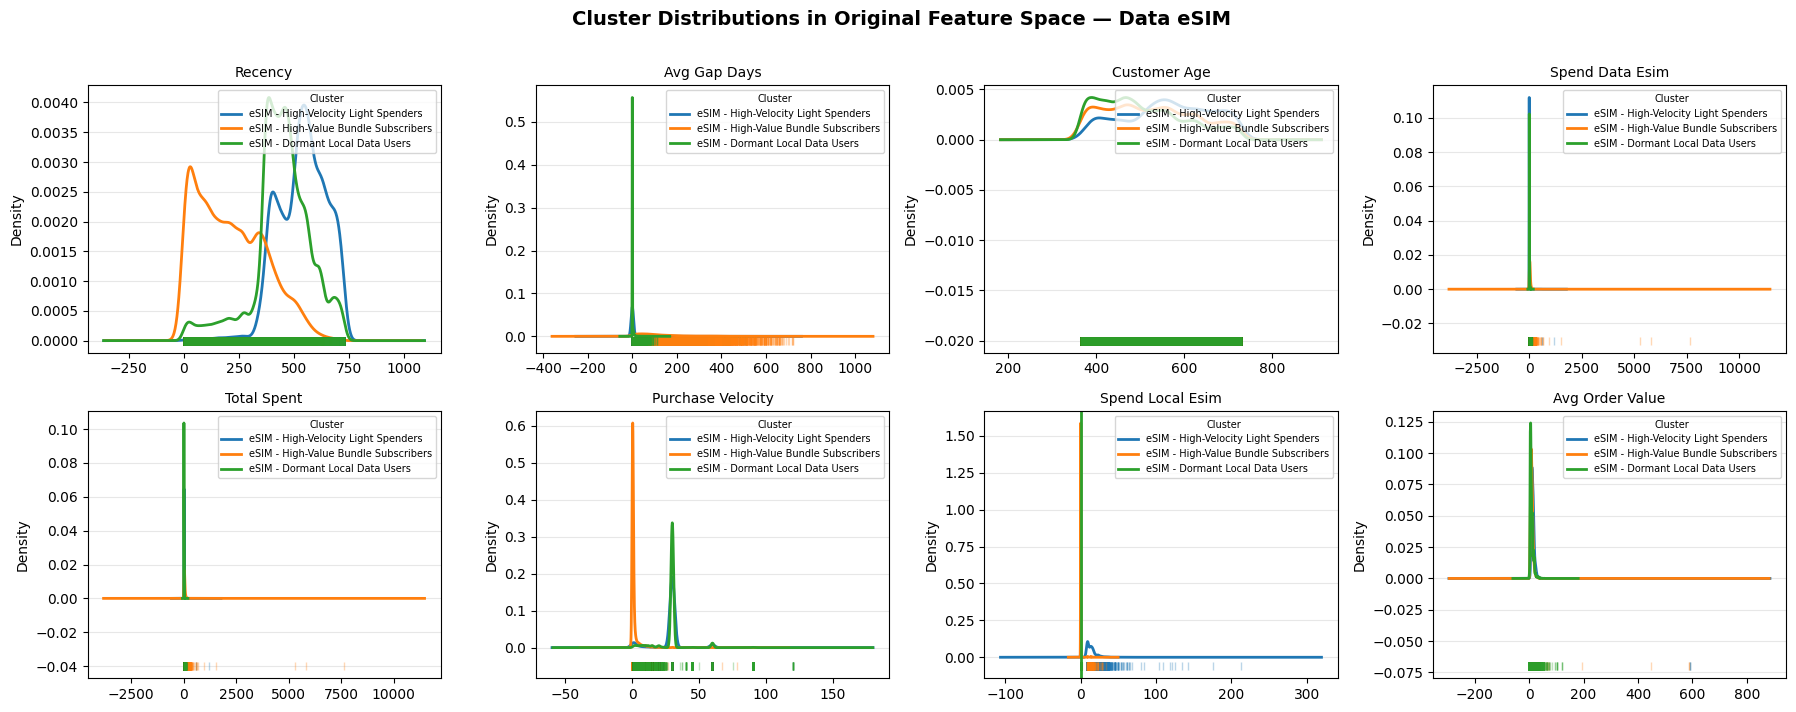

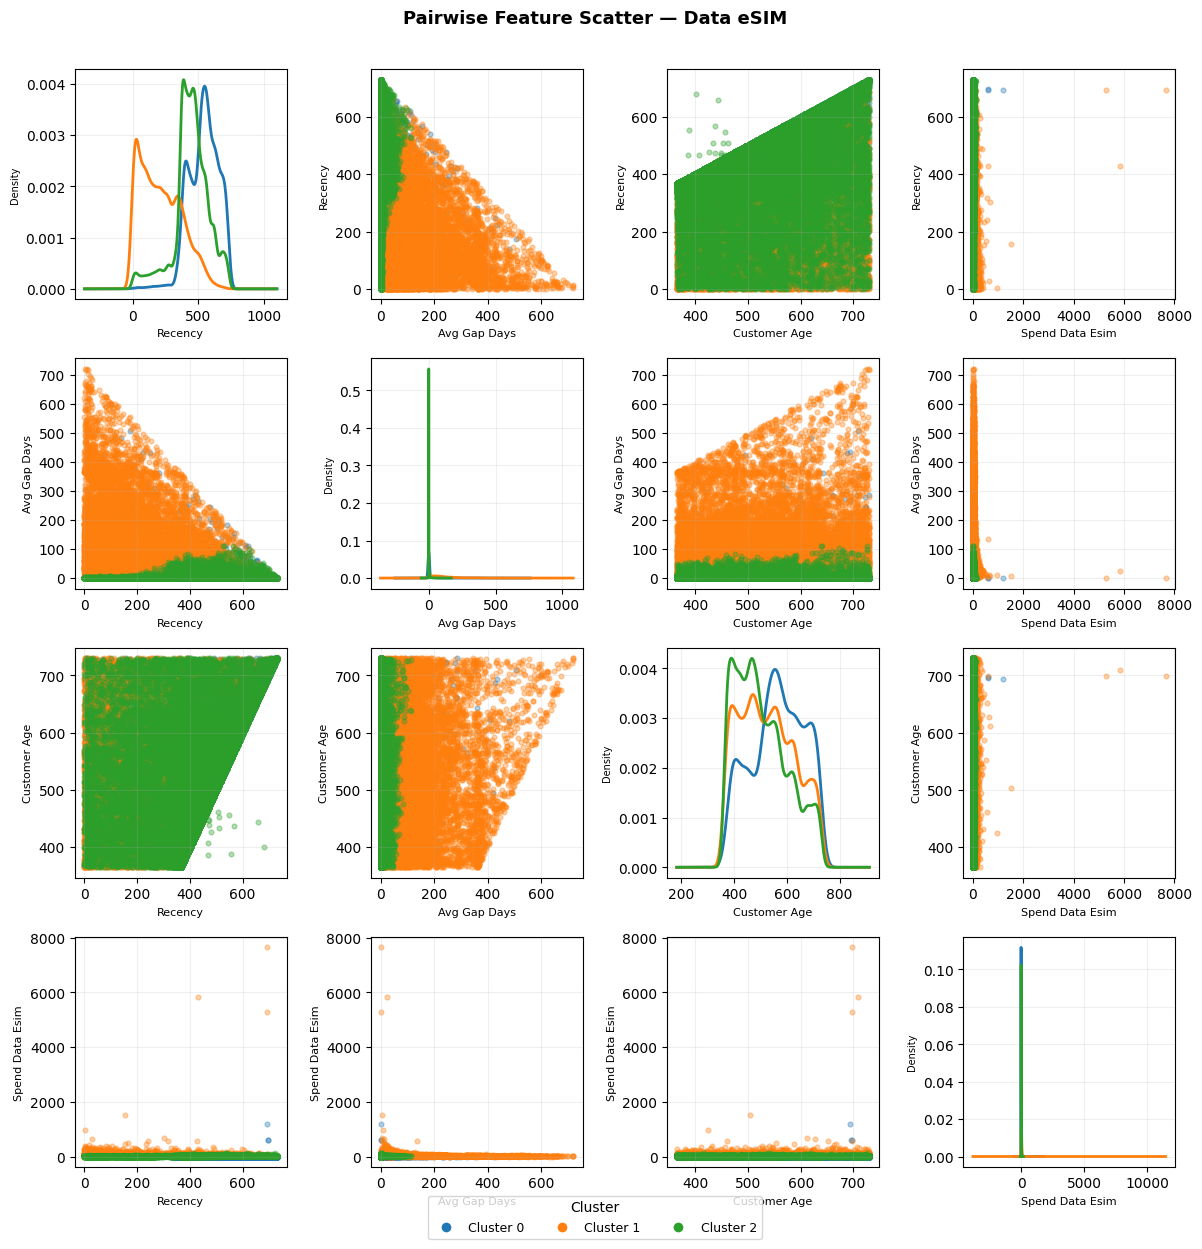

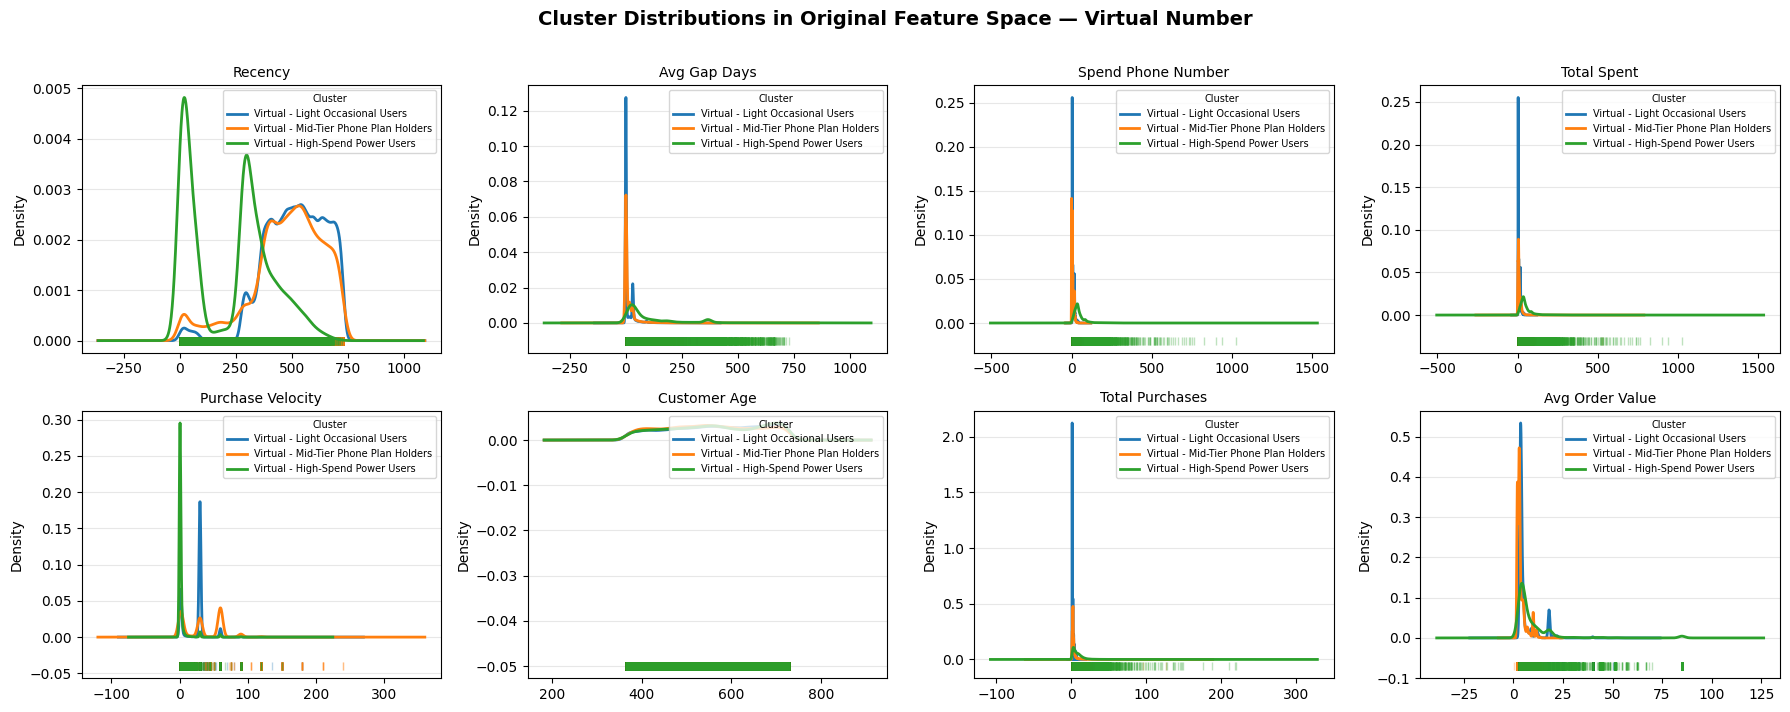

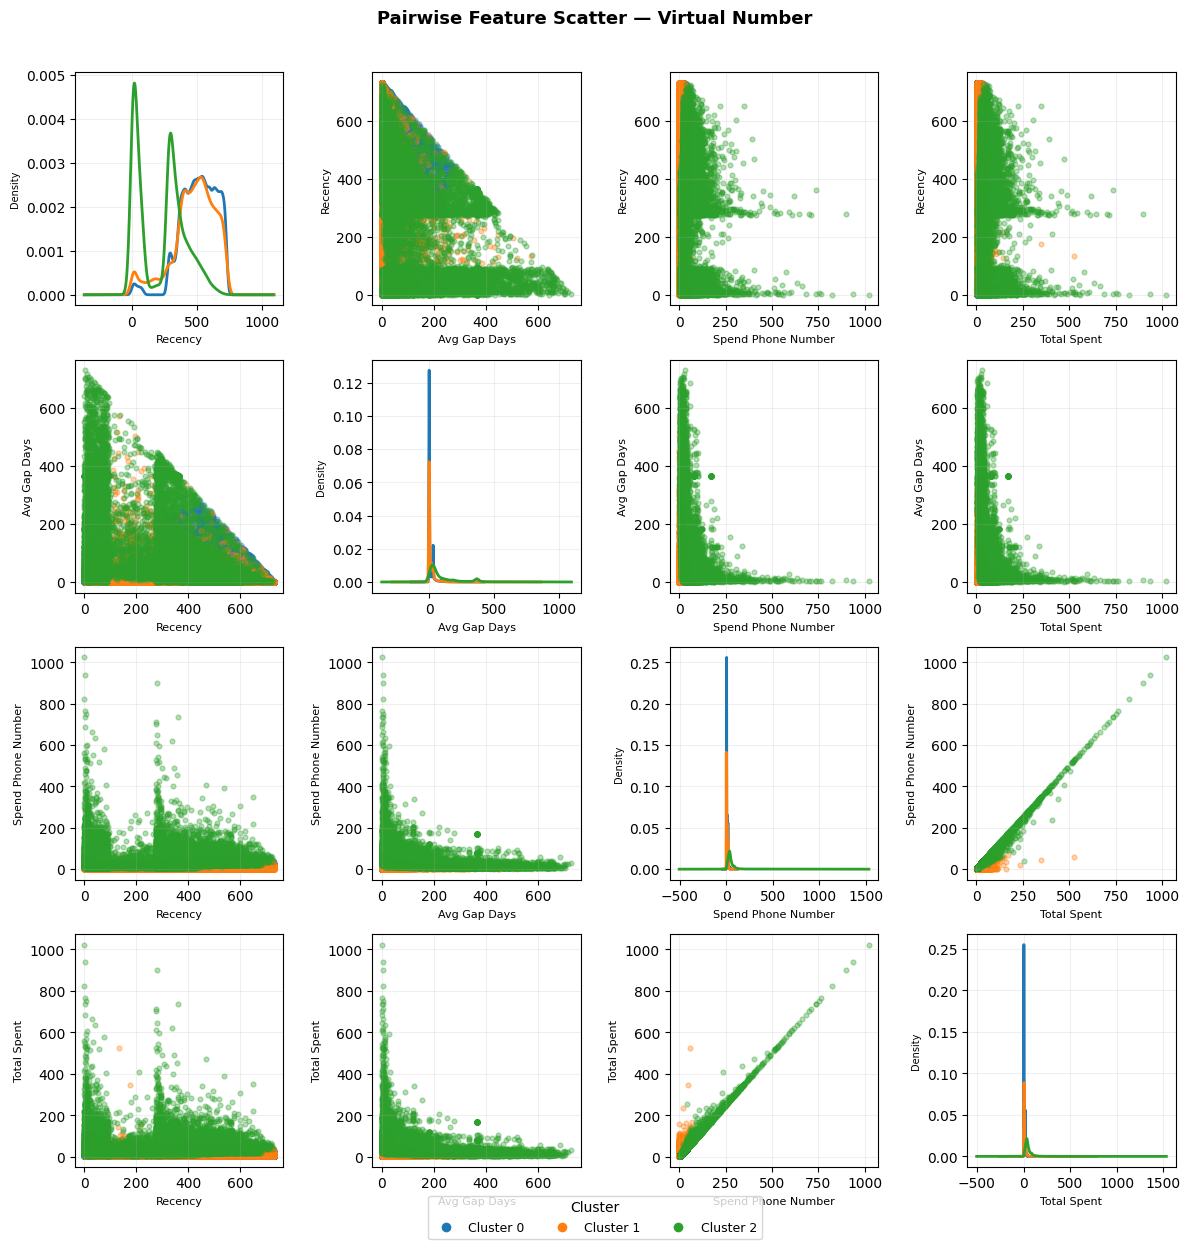

In [43]:
for clustered_df, group_name in [
    (calls_clustered,   'Calls'),
    (esim_clustered,    'Data eSIM'),
    (virtual_clustered, 'Virtual Number'),
]:

    print(f"{'='*180}")
    plot_original_features(clustered_df, group_name, top_n=8)
    plot_pairwise_scatter(clustered_df,  group_name, top_n=4)

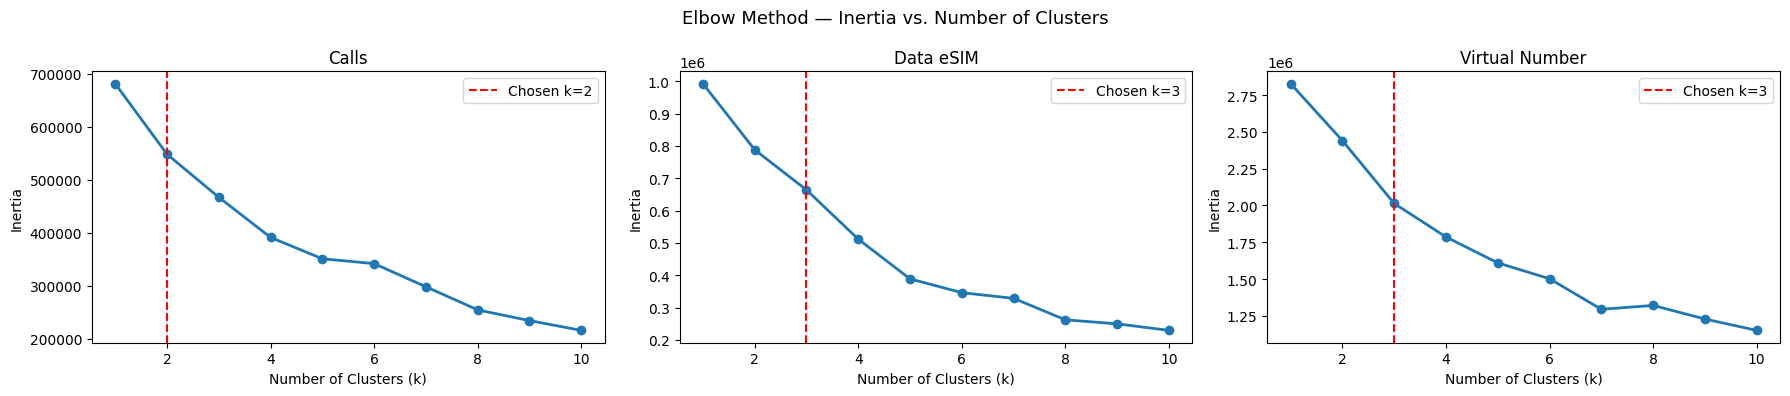

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle('Elbow Method — Inertia vs. Number of Clusters', fontsize=13)

groups = [
    (df_calls, calls_clients, 'Calls'),
    (df_esim, esim_clients, 'Data eSIM'),
    (df_virtual, virtual_clients, 'Virtual Number'),
]

chosen_k = [2, 3, 3]

for ax, (df_grp, clients, name), k in zip(axes, groups, chosen_k):
    feature_cols = [c for c in clients.columns if c != 'id_client']
    X = clients[feature_cols].fillna(0)
    X_scaled = StandardScaler().fit_transform(X)
    pca = PCA(n_components=0.90, random_state=42)
    X_pca = pca.fit_transform(X_scaled)

    inertias = []
    K_range = range(1, 11)
    for k_test in K_range:
        km = KMeans(n_clusters=k_test, random_state=42, n_init='auto')
        km.fit(X_pca)
        inertias.append(km.inertia_)

    ax.plot(K_range, inertias, marker='o', linewidth=2)
    ax.axvline(x=k, color='red', linestyle='--', label=f'Chosen k={k}')
    ax.set_title(name)
    ax.set_xlabel('Number of Clusters (k)')
    ax.set_ylabel('Inertia')
    ax.legend()

plt.tight_layout()
plt.show()

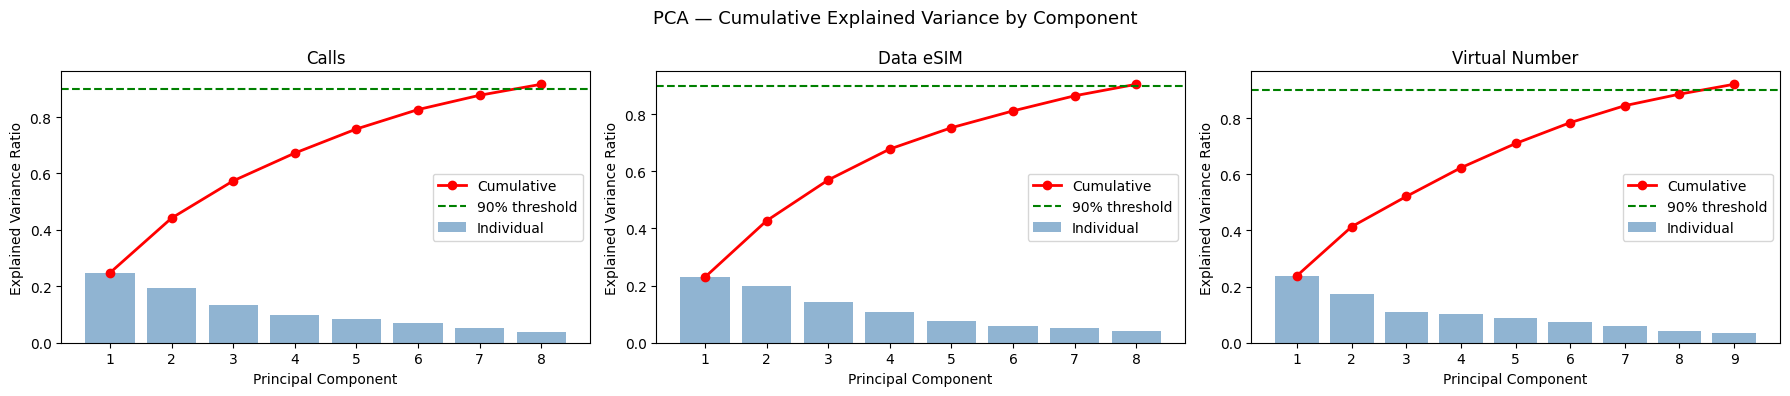

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle('PCA — Cumulative Explained Variance by Component', fontsize=13)

fitted_pcas = [
    (calls_pca, 'Calls'),
    (esim_pca, 'Data eSIM'),
    (virtual_pca, 'Virtual Number'),
]

for ax, (pca, name) in zip(axes, fitted_pcas):
    cumvar = np.cumsum(pca.explained_variance_ratio_)
    components = range(1, len(cumvar) + 1)

    ax.bar(components, pca.explained_variance_ratio_,
           alpha=0.6, label='Individual', color='steelblue')
    ax.plot(components, cumvar, marker='o', color='red',
            linewidth=2, label='Cumulative')
    ax.axhline(y=0.90, color='green', linestyle='--', label='90% threshold')
    ax.set_title(name)
    ax.set_xlabel('Principal Component')
    ax.set_ylabel('Explained Variance Ratio')
    ax.set_xticks(list(components))
    ax.legend()

plt.tight_layout()
plt.show()